# 02 EDA, funnel diagnostics and Top Issues

Notebook 02 creates the main diagnostic layer between the gold tables and the final reporting outputs. It starts from the weekly fact tables created in Notebook 01, checks them against the Notebook 01 quality files, measures funnel performance over time, compares segment behaviour against the same-week site baseline, and ranks the most important conversion issues for prioritisation.

---

## Purpose

- Build weekly funnel rates from the Notebook 01 fact tables
- Check the loaded weekly fact tables against the Notebook 01 quality files: `events_base_quality.json`, `gold_tables_sanity.json`, `pre_purchase_feature_validation.json`, and `table_dictionary.csv`
- Compare device, country, and channel performance across funnel transitions
- Estimate where weaker segment conversion may be contributing to lost purchases
- Create clean readable labels for dashboard tables and visuals
- Retain raw segment values separately for future checking
- Produce a weekly Top Issues table that supports the executive, segment issue, and decision summary pages
- Save the clean diagnostic CSV outputs directly to `powerbi_extracts/latest`, which is the final reporting folder used by Power BI and Notebook 04
- Display simple notebook graphs for EDA review and interpretation

---

## Process

1. Load the weekly session and funnel fact tables created in Notebook 01.
2. Load the Notebook 01 audit files so weekly coverage, row counts, purchase-session counts, and pre-purchase validation are checked against the actual saved outputs.
3. Calculate weekly funnel reach rates and step-to-step conversion rates.
4. Compare segment-level conversion against the same-week overall baseline.
5. Estimate lost next-step sessions and estimated lost purchases for weaker segment-step combinations.
6. Rank the highest-priority weekly issues using a simple impact and severity score.
7. Save `funnel_weekly_rates.csv`, `segment_step_metrics_weekly.csv`, and `top_issues_weekly.csv` to `powerbi_extracts/latest` for Power BI and Notebook 04.

# 1.0 Data imports and environment setup


In [1]:
#------------------------------------------------------------------------------
# 1.1 Imports and Drive setup
#------------------------------------------------------------------------------
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from google.colab import drive
from IPython.display import display

# Mount Drive to access saved project files
drive.mount("/content/drive", force_remount=True)

# Set notebook display options
pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 160)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

Mounted at /content/drive


# 2.0 Load Notebook 01 outputs and define helper functions

Notebook 02 starts from the clean weekly fact tables created by Notebook 01 rather than returning to the raw GA4 export. The code below defines the shared paths, uses the fixed final project date window for coverage reporting, loads the Notebook 01 fact tables and quality files, creates helpers, and prepares readable labels for later diagnostics while preserving the raw values used for audit checks.

**Process**:
1. Define the shared capstone folders and the Power BI latest folder used for final dashboard/reporting CSVs.
2. Load the Notebook 01 fact tables plus the saved quality files from `outputs/data_quality`.
3. Define helper functions for loading files, calculating rates, aggregating weekly tables, and saving outputs.
4. Create readable display labels for channel segments while keeping raw values in separate fields.
5. Standardise key date and label columns before analysis.


In [2]:
#------------------------------------------------------------------------------
# 2.1 Core config, folders, and helper functions
#------------------------------------------------------------------------------
CAPSTONE_DIR = Path("/content/drive/MyDrive/Capstone_Project")

OUTPUT_DIR = CAPSTONE_DIR / "outputs"
DQ_DIR = OUTPUT_DIR / "data_quality"
PBI_LATEST_DIR = CAPSTONE_DIR / "powerbi_extracts" / "latest"

START_DATE = "20201101"
END_DATE = "20210228"

EVENTS_QUALITY_PATH = DQ_DIR / "events_base_quality.json"
GOLD_SANITY_PATH = DQ_DIR / "gold_tables_sanity.json"
PRE_PURCHASE_VALIDATION_PATH = DQ_DIR / "pre_purchase_feature_validation.json"
TABLE_DICTIONARY_PATH = DQ_DIR / "table_dictionary.csv"
FACT_SESSIONS_PATH = PBI_LATEST_DIR / "fact_sessions_weekly.csv"
FACT_FUNNEL_PATH = PBI_LATEST_DIR / "fact_funnel_weekly.csv"

# Set issue ranking controls
MIN_EARLIER_STEP_SESSIONS = 100
TOP_ISSUES_PER_WEEK = 3

# Define the funnel order and transitions
FUNNEL_STEPS = ["view_item","add_to_cart","begin_checkout","add_shipping_info","add_payment_info","purchase"]
FUNNEL_PAIRS = list(zip(FUNNEL_STEPS[:-1], FUNNEL_STEPS[1:]))

PBI_LATEST_DIR.mkdir(parents=True, exist_ok=True)

# Print a simple section banner
def print_banner(title):
    print("\n" + "-" * 78); print(title); print("-" * 78)

# Load a JSON audit file from Drive
def load_json(path):
    return json.loads(path.read_text(encoding="utf-8"))

# Load a CSV file from Drive
def load_csv(path):
    return pd.read_csv(path)

# Clean labels so dashboard filters do not show blanks
def clean_label_series(series):
    return series.fillna("(not set)").astype(str).str.strip().replace({"": "(not set)", "nan": "(not set)", "None": "(not set)"})

# Safe vector divide used for rates
def safe_divide(numerator, denominator):
    numerator = pd.to_numeric(pd.Series(numerator), errors="coerce")
    denominator = pd.to_numeric(pd.Series(denominator), errors="coerce")
    return np.where(denominator > 0, numerator / denominator, np.nan)

# Weighted mean used when rolling up pre-averaged weekly metrics
def weighted_mean(values, weights):
    v = pd.to_numeric(values, errors="coerce"); w = pd.to_numeric(weights, errors="coerce")
    mask = v.notna() & w.notna()
    if mask.sum() == 0 or w.loc[mask].sum() == 0: return np.nan
    return float(np.average(v.loc[mask], weights=w.loc[mask]))

# Save a dataframe to CSV only
def save_csv(df, path):
    path.parent.mkdir(parents=True, exist_ok=True); df.to_csv(path, index=False)
    print("Saved ->", path)

# Aggregate weekly session rows to the chosen grouping level
def aggregate_sessions_weekly(df, group_cols):
    rows = []
    for keys, group in df.groupby(group_cols, dropna=False):
        if not isinstance(keys, tuple): keys = (keys,)
        n_sessions = int(group["n_sessions"].sum()); n_purchases = int(group["n_purchases"].sum())
        rows.append(dict(zip(group_cols, keys)) | {"n_sessions": n_sessions, "n_purchases": n_purchases,
            "purchase_rate": n_purchases / n_sessions if n_sessions > 0 else np.nan,
            "avg_session_duration_sec": weighted_mean(group["avg_session_duration_sec"], group["n_sessions"]),
            "avg_engagement_time_msec": weighted_mean(group["avg_engagement_time_msec"], group["n_sessions"])})
    return pd.DataFrame(rows)

# Aggregate weekly funnel rows to the chosen grouping level
def aggregate_funnel_weekly(df, group_cols):
    return df.groupby(group_cols + ["funnel_step"], dropna=False, as_index=False)["n_sessions_reaching_step"].sum()

# Percentile-style rank used in the issue score
def pct_rank(series):
    if len(series) == 0: return series
    if series.nunique(dropna=False) <= 1: return pd.Series(np.ones(len(series)), index=series.index)
    return series.rank(pct=True, method="average")


# Create readable funnel step labels
STEP_LABELS = {"view_item": "product view", "add_to_cart": "cart", "begin_checkout": "checkout", "add_shipping_info": "shipping", "add_payment_info": "payment", "purchase": "purchase"}

# Clean raw and previously formatted channel labels for dashboard tables and charts
def clean_channel_segment(value):
    import re
    raw_value = "(not set) / (not set)" if pd.isna(value) else str(value).strip()
    value_lower = raw_value.lower().strip()

    # Map common raw channel values to cleaner names
    label_map = {
        "(direct) / (none)": "Direct traffic",
        "(direct) / organic": "Direct organic traffic",
        "(direct) / referral": "Direct referral traffic",
        "(not set) / (not set)": "Unknown traffic",
        "(data deleted) / (data deleted)": "Unknown traffic",
        "(data deleted) / organic": "Unknown organic traffic",
        "(data deleted) / referral": "Unknown referral traffic",
        "<other> / <other>": "Other channels",
        "<other> / organic": "Other organic traffic",
        "<other> / referral": "Other referral traffic",
        "<other> / (data deleted)": "Unknown traffic",
        "google / organic": "Google organic traffic",
        "google / cpc": "Google paid search traffic",
        "google / referral": "Google referral traffic",
        "google / email": "Google email traffic",
        "google / <other>": "Other channels",
        "partners / affiliate": "Partners affiliate traffic",
        "partners / organic": "Partners organic traffic",
        "partners / (data deleted)": "Unknown traffic",
        "shop.googlemerchandisestore.com / referral": "Google Merch Store referral traffic",
        "shop.googlemerchandisestore.com / organic": "Google Merch Store organic traffic",
        "googlemerchandisestore.com / referral": "Google Merch Store referral traffic",
        "googlemerchandisestore.com / organic": "Google Merch Store organic traffic",
        "your.googlemerchandisestore.com / referral": "Google Merch Store referral traffic",
        "admin.googlemerchandisestore.com / referral": "Google Merch Store admin referral traffic",
        "analytics.google.com / referral": "Google Analytics referral traffic",
        "analytics.google.com / organic": "Google Analytics organic traffic",
        "support.google.com / referral": "Google support referral traffic",
        "sites.google.com / referral": "Google sites referral traffic",
        "mail.google.com / referral": "Google Mail referral traffic",
        "docs.google.com / referral": "Google Docs referral traffic",
        "groups.google.com / referral": "Google Groups referral traffic",
        "keep.google.com / referral": "Google Keep referral traffic",
        "creatoracademy.youtube.com / referral": "YouTube Creator Academy referral traffic",
        "youtube.com / referral": "YouTube referral traffic",
        "m.youtube.com / referral": "YouTube referral traffic",
        "amp.reddit.com / referral": "Reddit referral traffic",
        "reddit.com / referral": "Reddit referral traffic",
        "quora.com / referral": "Quora referral traffic",
        "pinterest.com / referral": "Pinterest referral traffic",
        "theverge.com / referral": "The Verge referral traffic",
        "qiita.com / referral": "Qiita referral traffic",
        "udemy.com / referral": "Udemy referral traffic",
        "qwiklabs.com / referral": "Qwiklabs referral traffic",
        "run.qwiklabs.com / referral": "Qwiklabs referral traffic",
        "perksatwork.com / referral": "Perks at Work referral traffic",
        "yandex.ru / referral": "Yandex referral traffic",
        "yandex.kz / referral": "Yandex referral traffic",
        "yahoo / organic": "Yahoo organic traffic",
        "baidu / organic": "Baidu organic traffic",
        "bing / organic": "Bing organic traffic",
        "t.co / referral": "Twitter/X referral traffic",
        "web.skype.com / referral": "Skype referral traffic",
        "coursera.org / referral": "Coursera referral traffic",
        "facebook.com / referral": "Facebook referral traffic",
        "m.facebook.com / referral": "Facebook referral traffic",
        "l.facebook.com / referral": "Facebook referral traffic",
        "facebook / email": "Facebook email traffic"}
    # Return direct matches first
    if value_lower in label_map:
        return label_map[value_lower]

    # Catch ad-frame and ad-network labels before title-casing
    if "safeframe" in value_lower or "googlesyndication" in value_lower:
        return "Google ad frame referral traffic"
    if "doubleclick" in value_lower or "2mdn.net" in value_lower:
        return "Google ad network referral traffic"
    if "googleusercontent" in value_lower:
        return "Google hosted referral traffic"
    if "appspot.com" in value_lower:
        return "Google hosted app referral traffic"

    # Group search and technical sources that create noisy labels
    if "search.yahoo.com" in value_lower:
        return "Yahoo search traffic"
    if "search.aol.com" in value_lower:
        return "AOL search referral traffic"
    if "ask.com" in value_lower:
        return "Ask search referral traffic"
    if "startpage.com" in value_lower:
        return "Startpage search referral traffic"
    if "sm.cn" in value_lower:
        return "SM.cn search referral traffic"

    # Group long hashed or technical labels before title-casing
    has_long_hash = re.search(r"[a-f0-9]{24,}", value_lower) is not None
    is_long_technical = len(value_lower) > 55 or value_lower.count(".") >= 3

    if has_long_hash or is_long_technical:
        if "referral" in value_lower:
            return "Other technical referral traffic"
        if "organic" in value_lower:
            return "Other technical organic traffic"
        return "Other technical traffic"

    # Clean normal source / medium pairs
    if " / " in raw_value:
        source, medium = raw_value.split(" / ", 1)
        source_clean = source.strip().lower()
        medium_clean = medium.strip().lower()

        # Collapse unknown and other source values
        if source_clean in ["<other>", "other"]:
            return "Other channels" if medium_clean in ["<other>", "other", "(data deleted)"] else f"Other {medium_clean} traffic"
        if source_clean in ["(not set)", "(data deleted)", "data deleted"]:
            return "Unknown traffic" if medium_clean in ["(not set)", "(none)", "(data deleted)"] else f"Unknown {medium_clean} traffic"
        if medium_clean in ["(not set)", "(none)", "(data deleted)", "<other>"]:
            return f"{source_clean.replace('_', ' ').replace('-', ' ').title()} traffic"

        source_display = source_clean.replace("www.", "").replace("_", " ").replace("-", " ")
        source_display = source_display.replace(".com", "").replace(".org", "").replace(".net", "").replace(".ru", "")
        source_display = source_display.title().replace("Youtube", "YouTube").replace("T.Co", "Twitter/X")
        return f"{source_display} {medium_clean} traffic"

    return raw_value.replace("_", " ").replace("-", " ").title()

# Convert technical segment values into short  phrases
def format_segment_label(segment_type, segment_value):
    value = str(segment_value).strip()
    if segment_type == "device_category":
        return f"{value.title()} users"
    if segment_type == "geo_country":
        return "Unknown country users" if value in ["(not set)", "not set", "nan", "None"] else f"{value} users"
    if segment_type == "channel_segment":
        return clean_channel_segment(value)
    return value

# Create a readable dashboard label while keeping raw fields separate
def format_issue_label(row):
    segment_label = row["segment_value_clean"]
    step_from = STEP_LABELS[row["step_from"]]
    step_to = STEP_LABELS[row["step_to"]]
    return f"{segment_label}: {step_from} to {step_to} drop-off"

print("FACT_SESSIONS_PATH:", FACT_SESSIONS_PATH)
print("FACT_FUNNEL_PATH  :", FACT_FUNNEL_PATH)

FACT_SESSIONS_PATH: /content/drive/MyDrive/Capstone_Project/powerbi_extracts/latest/fact_sessions_weekly.csv
FACT_FUNNEL_PATH  : /content/drive/MyDrive/Capstone_Project/powerbi_extracts/latest/fact_funnel_weekly.csv


In [3]:
#------------------------------------------------------------------------------
# 2.2 Load and clean Notebook 01 outputs
#------------------------------------------------------------------------------
print_banner("2.2 Load and clean Notebook 01 outputs")

# Load Notebook 01 tables and audit files
events_base_quality = load_json(EVENTS_QUALITY_PATH)
gold_sanity = load_json(GOLD_SANITY_PATH)
pre_purchase_validation = load_json(PRE_PURCHASE_VALIDATION_PATH)
table_dictionary = load_csv(TABLE_DICTIONARY_PATH)
fact_sessions_weekly = load_csv(FACT_SESSIONS_PATH)
fact_funnel_weekly = load_csv(FACT_FUNNEL_PATH)


# Clean key labels used in joins and filters
label_cols = ["device_category","geo_country","channel_source","channel_medium","channel_segment"]
for col in label_cols:
    fact_sessions_weekly[col] = clean_label_series(fact_sessions_weekly[col])
for col in label_cols + ["funnel_step"]:
    fact_funnel_weekly[col] = clean_label_series(fact_funnel_weekly[col])

# Keep raw channel values and add cleaner display labels
for df in [fact_sessions_weekly, fact_funnel_weekly]:
    df["channel_segment_raw"] = df["channel_segment"]
    df["channel_segment_display"] = df["channel_segment_raw"].map(clean_channel_segment)

# Convert reporting weeks to datetime
fact_sessions_weekly["week_start_date"] = pd.to_datetime(fact_sessions_weekly["week_start_date"])
fact_funnel_weekly["week_start_date"] = pd.to_datetime(fact_funnel_weekly["week_start_date"])

# Convert saved table counts into a dataframe
table_counts_df = pd.DataFrame(gold_sanity["table_counts"])

print("Project date window:", START_DATE, "to", END_DATE)
print("Actual event date range:", events_base_quality["min_event_date"], "to", events_base_quality["max_event_date"])
print("fact_sessions_weekly shape:", fact_sessions_weekly.shape)
print("fact_funnel_weekly shape  :", fact_funnel_weekly.shape)
session_preview_cols = ["week_start_date","device_category","geo_country","channel_segment","channel_segment_display","n_sessions","n_purchases","purchase_rate"]
funnel_preview_cols = ["week_start_date","device_category","geo_country","channel_segment","channel_segment_display","funnel_step","n_sessions_reaching_step"]
display(fact_sessions_weekly[session_preview_cols].head(5))
display(fact_funnel_weekly[funnel_preview_cols].head(5))


------------------------------------------------------------------------------
2.2 Load and clean Notebook 01 outputs
------------------------------------------------------------------------------
Project date window: 20201101 to 20210228
Actual event date range: 20201101 to 20210131
fact_sessions_weekly shape: (22457, 13)
fact_funnel_weekly shape  : (27607, 10)


,week_start_date,device_category,geo_country,channel_segment,channel_segment_display,n_sessions,n_purchases,purchase_rate
0,2020-10-26,desktop,(not set),(direct) / (none),Direct traffic,1,0,0.0000
1,2020-10-26,desktop,(not set),<Other> / <Other>,Other channels,3,0,0.0000
2,2020-10-26,desktop,(not set),<Other> / organic,Other organic traffic,1,0,0.0000
3,2020-10-26,desktop,(not set),<Other> / referral,Other referral traffic,1,0,0.0000
4,2020-10-26,desktop,(not set),google / organic,Google organic traffic,3,0,0.0000


,week_start_date,device_category,geo_country,channel_segment,channel_segment_display,funnel_step,n_sessions_reaching_step
0,2020-10-26,desktop,(not set),<Other> / <Other>,Other channels,view_item,1
1,2020-10-26,desktop,(not set),<Other> / referral,Other referral traffic,add_shipping_info,1
2,2020-10-26,desktop,(not set),<Other> / referral,Other referral traffic,begin_checkout,1
3,2020-10-26,desktop,(not set),<Other> / referral,Other referral traffic,view_item,1
4,2020-10-26,desktop,(not set),google / organic,Google organic traffic,view_item,1


# 3.0 Review weekly coverage and analysis readiness

The first analysis step reviews the weekly fact tables before building funnel diagnostics. These tables are compared with the Notebook 01 quality files: `events_base_quality.json`, `gold_tables_sanity.json`, `pre_purchase_feature_validation.json`, and `table_dictionary.csv`. This keeps Notebook 02 aligned with the actual saved table names, row counts and pre-purchase validation fields.

Notebook 01 checks that funnel reach is monotonic from `view_item` through `add_payment_info`.

**Process**:
1. Aggregate weekly sessions to the overall site level to create a simple baseline view.
2. Show the available `week_start_date` values beside the fixed project date window and actual event-date range.
3. Compare loaded fact table row counts with Notebook 01's table counts and table dictionary.
4. Compare total sessions and purchase sessions with the Notebook 01 grain and funnel reach audit fields.
5. Display the pre-purchase validation summary
6. Summarise the largest device, country, and channel segments to understand which groups are large enough for reliable diagnostics.


In [4]:
#------------------------------------------------------------------------------
# 3.1 Weekly coverage and segment scale checks
#------------------------------------------------------------------------------
print_banner("3.1 Weekly coverage and segment scale checks")

# Build the weekly site-level baseline
overall_sessions_weekly = aggregate_sessions_weekly(fact_sessions_weekly, ["week_start_date"]).sort_values("week_start_date").reset_index(drop=True)

# Convert the fixed date window to dates
start_date = pd.to_datetime(START_DATE, format="%Y%m%d")
end_date = pd.to_datetime(END_DATE, format="%Y%m%d")

# Summarise the reporting coverage
coverage_df = pd.DataFrame([{
    "query_START_DATE": START_DATE,
    "query_END_DATE": END_DATE,
    "actual_min_event_date": events_base_quality["min_event_date"],
    "actual_max_event_date": events_base_quality["max_event_date"],
    "n_weeks": overall_sessions_weekly["week_start_date"].nunique(),
    "first_reporting_week": overall_sessions_weekly["week_start_date"].min().date(),
    "last_reporting_week": overall_sessions_weekly["week_start_date"].max().date(),
    "total_sessions": int(overall_sessions_weekly["n_sessions"].sum()),
    "total_purchase_sessions": int(overall_sessions_weekly["n_purchases"].sum()),
    "overall_purchase_rate": overall_sessions_weekly["n_purchases"].sum() / overall_sessions_weekly["n_sessions"].sum()}])

# Check loaded rows against Notebook 01 audit counts
table_count_map = table_counts_df.set_index("table_name")["n_rows"].to_dict()
table_dictionary_map = table_dictionary.set_index("table_name")["n_rows"].to_dict()
input_table_check_df = pd.DataFrame([
    {"table_name": "fact_sessions_weekly", "loaded_rows": len(fact_sessions_weekly), "notebook01_table_count_rows": int(table_count_map["fact_sessions_weekly"]), "table_dictionary_rows": int(table_dictionary_map["fact_sessions_weekly"])},
    {"table_name": "fact_funnel_weekly", "loaded_rows": len(fact_funnel_weekly), "notebook01_table_count_rows": int(table_count_map["fact_funnel_weekly"]), "table_dictionary_rows": int(table_dictionary_map["fact_funnel_weekly"])}])

# Pull saved quality checks for alignment
grain_checks = gold_sanity["grain_checks"]
funnel_reach_counts = gold_sanity["funnel_reach_counts"]
integrity_checks = gold_sanity["integrity_checks"]
alignment_df = pd.DataFrame([{
    "weekly_session_sum": int(overall_sessions_weekly["n_sessions"].sum()),
    "notebook01_session_rows": int(grain_checks["n_sessions"]),
    "weekly_purchase_session_sum": int(overall_sessions_weekly["n_purchases"].sum()),
    "notebook01_purchase_sessions": int(funnel_reach_counts["sessions_reached_purchase"]),
    "notebook01_order_records": int(grain_checks["n_orders"]),
    "duplicate_session_key_groups": int(integrity_checks["n_duplicate_session_key_groups"]),
    "extra_session_rows": int(integrity_checks["n_extra_session_rows"]),
    "pre_purchase_validation_passed": bool(gold_sanity["pre_purchase_feature_validation_passed"]),
    "funnel_monotonic_until_payment": bool(gold_sanity["funnel_monotonic_until_payment"]),
    "purchase_sessions_can_skip_prior_steps": bool(gold_sanity["purchase_sessions_can_skip_prior_steps"])}])

pre_purchase_validation_df = pd.DataFrame([pre_purchase_validation])

# Summarise the largest segment groups
segment_scale_frames = []
for segment_type, col in [("device_category","device_category"), ("geo_country","geo_country"), ("channel_segment","channel_segment")]:
    tmp = fact_sessions_weekly.groupby(col, as_index=False)[["n_sessions","n_purchases"]].sum().sort_values("n_sessions", ascending=False).head(8)
    tmp["segment_type"] = segment_type; tmp = tmp.rename(columns={col: "segment_value"})
    tmp["purchase_rate"] = safe_divide(tmp["n_purchases"], tmp["n_sessions"])
    segment_scale_frames.append(tmp[["segment_type","segment_value","n_sessions","n_purchases","purchase_rate"]])

# Combine segment scale summaries
segment_scale_df = pd.concat(segment_scale_frames, ignore_index=True)
segment_scale_df["segment_value_clean"] = segment_scale_df.apply(lambda r: format_segment_label(r["segment_type"], r["segment_value"]), axis=1)

print("Weekly coverage summary")
display(coverage_df)
print("\n")
print("Loaded fact-table row checks")
display(input_table_check_df)
print("\n")
print("Notebook 01 alignment check")
display(alignment_df)
print("\n")
print("Pre-purchase validation check")
display(pre_purchase_validation_df)
print("\n")
print("Largest segment groups")
scale_cols = ["segment_type","segment_value_clean","segment_value","n_sessions","n_purchases","purchase_rate"]
display(segment_scale_df[scale_cols])


------------------------------------------------------------------------------
3.1 Weekly coverage and segment scale checks
------------------------------------------------------------------------------
Weekly coverage summary


,query_START_DATE,query_END_DATE,actual_min_event_date,actual_max_event_date,n_weeks,first_reporting_week,last_reporting_week,total_sessions,total_purchase_sessions,overall_purchase_rate
0,20201101,20210228,20201101,20210131,14,2020-10-26,2021-01-25,360129,4848,0.0135




Loaded fact-table row checks


,table_name,loaded_rows,notebook01_table_count_rows,table_dictionary_rows
0,fact_sessions_weekly,22457,22457,22457
1,fact_funnel_weekly,27607,27607,27607




Notebook 01 alignment check


,weekly_session_sum,notebook01_session_rows,weekly_purchase_session_sum,notebook01_purchase_sessions,notebook01_order_records,duplicate_session_key_groups,extra_session_rows,pre_purchase_validation_passed,funnel_monotonic_until_payment,purchase_sessions_can_skip_prior_steps
0,360129,360129,4848,4848,5281,0,0,True,True,False




Pre-purchase validation check


,n_session_rows_checked,n_session_event_count_mismatches,n_item_rows_checked,n_item_count_mismatches,n_post_purchase_funnel_steps
0,360129,0,360129,0,0




Largest segment groups


,segment_type,segment_value_clean,segment_value,n_sessions,n_purchases,purchase_rate
0,device_category,Desktop users,desktop,208942,2749,0.0132
1,device_category,Mobile users,mobile,143185,1995,0.0139
2,device_category,Tablet users,tablet,8002,104,0.0130
3,geo_country,United States users,United States,158155,2117,0.0134
4,geo_country,India users,India,33769,449,0.0133
5,geo_country,Canada users,Canada,26824,390,0.0145
6,geo_country,United Kingdom users,United Kingdom,11327,151,0.0133
7,geo_country,France users,France,7162,102,0.0142
8,geo_country,Spain users,Spain,6667,99,0.0148
9,geo_country,Germany users,Germany,6393,81,0.0127


# 4.0 Build overall weekly funnel rates

The overall funnel rate table provides the main time series view of how users move through the ecommerce journey. It combines weekly session totals with weekly funnel-step reach counts, then calculates reach rates, step conversion rates, and purchase rates for the dashboard and reporting layer.

This notebook keeps the full six step funnel, including `add_shipping_info`, because the Top Issues logic needs to detect shipping-to-payment friction. The dashboard can still use a simplified high-level funnel if needed, but this diagnostic table preserves the more detailed transition structure.

**Process**:
1. Aggregate funnel step counts across all segments to create one weekly site level funnel view.
2. Join the funnel counts to weekly session and purchase totals from the session fact table.
3. Pivot the funnel steps into clear count columns for product view, cart, checkout, shipping, payment, and purchase.
4. Calculate weekly reach rates and step-to-step conversion rates using safe division logic.
5. Save `funnel_weekly_rates.csv` directly to the Power BI latest folder.
6. Display simple weekly charts that show session volume, purchase rate, latest-week funnel reach, and step-to-step conversion patterns.

In [5]:
#------------------------------------------------------------------------------
# 4.1 Create and save the weekly funnel-rate table
#------------------------------------------------------------------------------
print_banner("4.1 Create and save the weekly funnel-rate table")

# Aggregate funnel counts to the weekly site level
overall_funnel_long = aggregate_funnel_weekly(fact_funnel_weekly, ["week_start_date"])
overall_funnel_wide = overall_funnel_long.pivot(index="week_start_date", columns="funnel_step", values="n_sessions_reaching_step").fillna(0).reset_index()

# Join session totals with funnel-step counts
funnel_weekly_rates = overall_sessions_weekly.merge(overall_funnel_wide[["week_start_date"] + FUNNEL_STEPS], on="week_start_date", how="left")
funnel_weekly_rates["pct_sessions_reaching_view_item"] = safe_divide(funnel_weekly_rates["view_item"], funnel_weekly_rates["n_sessions"])

# Calculate step conversion rates and nonstandard flags
nonstandard_cols = []
for step_from, step_to in FUNNEL_PAIRS:
    rate_col = f"{step_from}_to_{step_to}_rate"
    flag_col = f"{step_from}_to_{step_to}_nonstandard_flag"
    funnel_weekly_rates[flag_col] = funnel_weekly_rates[step_to] > funnel_weekly_rates[step_from]
    funnel_weekly_rates[rate_col] = np.minimum(safe_divide(funnel_weekly_rates[step_to], funnel_weekly_rates[step_from]), 1.0)
    nonstandard_cols.append(flag_col)

# Add overall purchase rate and final flags
funnel_weekly_rates["overall_purchase_rate"] = safe_divide(funnel_weekly_rates["n_purchases"], funnel_weekly_rates["n_sessions"])
funnel_weekly_rates["any_nonstandard_step_flag"] = funnel_weekly_rates[nonstandard_cols].any(axis=1)
funnel_weekly_rates = funnel_weekly_rates.sort_values("week_start_date").reset_index(drop=True)

save_csv(funnel_weekly_rates, PBI_LATEST_DIR / "funnel_weekly_rates.csv")

summary_cols = ["week_start_date","n_sessions","n_purchases","overall_purchase_rate","view_item","add_to_cart","begin_checkout","purchase","any_nonstandard_step_flag"]
display(funnel_weekly_rates[summary_cols])


------------------------------------------------------------------------------
4.1 Create and save the weekly funnel-rate table
------------------------------------------------------------------------------
Saved -> /content/drive/MyDrive/Capstone_Project/powerbi_extracts/latest/funnel_weekly_rates.csv


,week_start_date,n_sessions,n_purchases,overall_purchase_rate,view_item,add_to_cart,begin_checkout,purchase,any_nonstandard_step_flag
0,2020-10-26,2625,13,0.0050,537.0000,1.0000,95.0000,13.0000,True
1,2020-11-02,24991,249,0.0100,"5,527.0000",0.0000,884.0000,249.0000,True
2,2020-11-09,22508,341,0.0152,"5,563.0000",0.0000,"1,042.0000",341.0000,True
3,2020-11-16,25914,374,0.0144,"6,621.0000",530.0000,"1,046.0000",374.0000,True
4,2020-11-23,27780,515,0.0185,"6,498.0000","1,242.0000","1,278.0000",515.0000,True
5,2020-11-30,31088,590,0.0190,"7,782.0000","2,616.0000","1,419.0000",590.0000,False
6,2020-12-07,38729,772,0.0199,"8,218.0000","2,709.0000","1,582.0000",772.0000,False
7,2020-12-14,33411,549,0.0164,"7,074.0000","2,084.0000","1,015.0000",549.0000,True
8,2020-12-21,22083,233,0.0106,"4,112.0000",981.0000,416.0000,233.0000,False
9,2020-12-28,20444,138,0.0068,"3,110.0000",655.0000,261.0000,138.0000,False



------------------------------------------------------------------------------
4.2 Display weekly funnel graphs
------------------------------------------------------------------------------


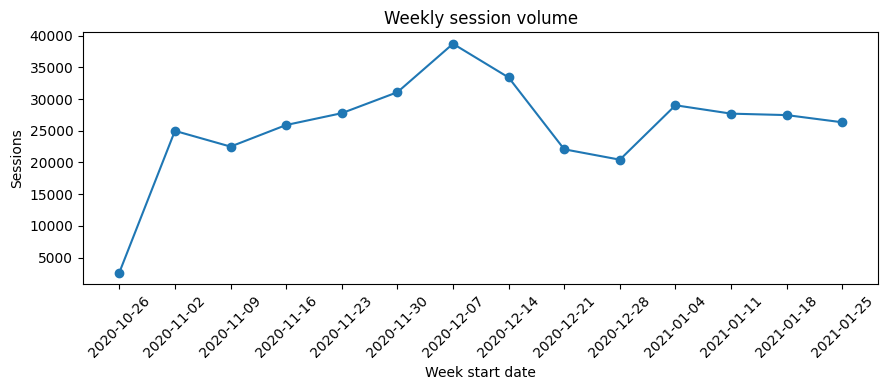

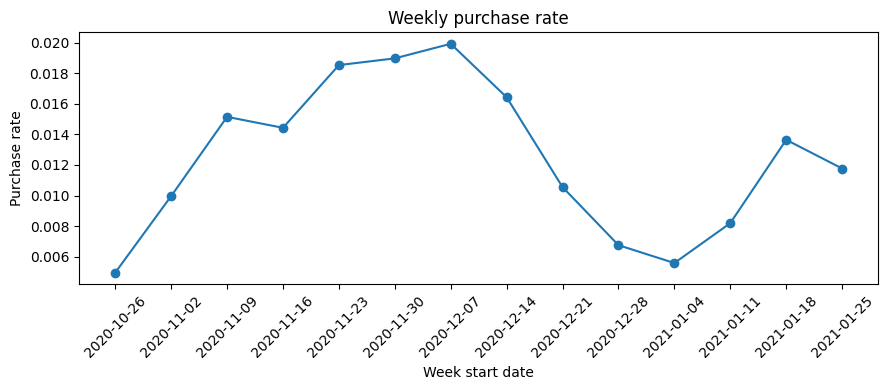

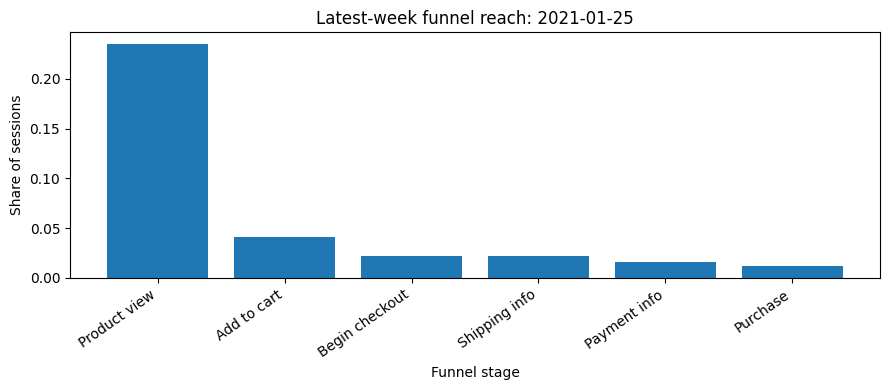

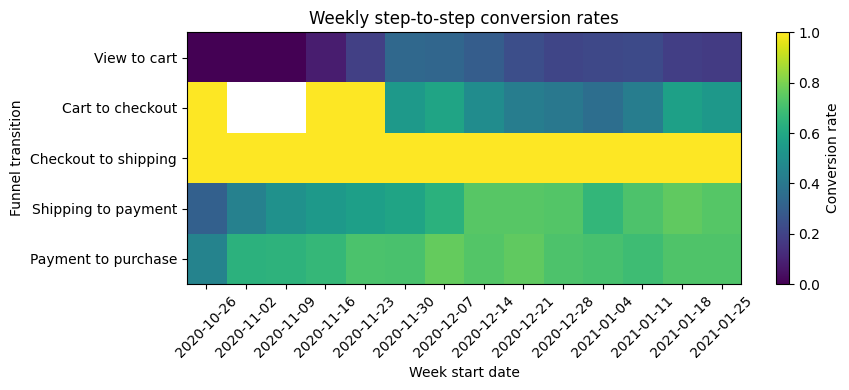

In [6]:
#------------------------------------------------------------------------------
# 4.2 Display weekly funnel graphs
#------------------------------------------------------------------------------
print_banner("4.2 Display weekly funnel graphs")

# Prepare week labels for plotting
plot_df = funnel_weekly_rates.copy()
plot_df["week_label"] = plot_df["week_start_date"].dt.strftime("%Y-%m-%d")

# Show overall demand and conversion movement
plt.figure(figsize=(9, 4))
plt.plot(plot_df["week_label"], plot_df["n_sessions"], marker="o")
plt.title("Weekly session volume")
plt.xlabel("Week start date")
plt.ylabel("Sessions")
plt.xticks(rotation=45)
plt.tight_layout(); plt.show()

plt.figure(figsize=(9, 4))
plt.plot(plot_df["week_label"], plot_df["overall_purchase_rate"], marker="o")
plt.title("Weekly purchase rate")
plt.xlabel("Week start date")
plt.ylabel("Purchase rate")
plt.xticks(rotation=45)
plt.tight_layout(); plt.show()

# Show where the latest-week funnel narrows
latest_week = funnel_weekly_rates["week_start_date"].max()
latest_funnel = funnel_weekly_rates[funnel_weekly_rates["week_start_date"].eq(latest_week)].iloc[0]
funnel_labels = ["Product view","Add to cart","Begin checkout","Shipping info","Payment info","Purchase"]
funnel_counts = [latest_funnel[s] for s in FUNNEL_STEPS]
funnel_share = [latest_funnel[s] / latest_funnel["n_sessions"] if latest_funnel["n_sessions"] > 0 else np.nan for s in FUNNEL_STEPS]

plt.figure(figsize=(9, 4))
plt.bar(funnel_labels, funnel_share)
plt.title(f"Latest-week funnel reach: {latest_week.date()}")
plt.xlabel("Funnel stage")
plt.ylabel("Share of sessions")
plt.xticks(rotation=35, ha="right")
plt.tight_layout(); plt.show()

# Make weekly step conversion easier to scan
heatmap_cols = [f"{a}_to_{b}_rate" for a, b in FUNNEL_PAIRS]
heatmap_labels = ["View to cart","Cart to checkout","Checkout to shipping","Shipping to payment","Payment to purchase"]
heatmap_df = funnel_weekly_rates[["week_start_date"] + heatmap_cols].copy()
heatmap_df["week_label"] = heatmap_df["week_start_date"].dt.strftime("%Y-%m-%d")
heatmap_df = heatmap_df.set_index("week_label")[heatmap_cols]

plt.figure(figsize=(9, 4))
plt.imshow(heatmap_df.T, aspect="auto")
plt.xticks(range(len(heatmap_df.index)), heatmap_df.index, rotation=45)
plt.yticks(range(len(heatmap_labels)), heatmap_labels)
plt.title("Weekly step-to-step conversion rates")
plt.xlabel("Week start date")
plt.ylabel("Funnel transition")
plt.colorbar(label="Conversion rate")
plt.tight_layout(); plt.show()

# 5.0 Build segment diagnostics

The segment diagnostics compare each device, country, and channel group against the same week overall funnel baseline. This turns the funnel analysis from a general performance view into a practical diagnostic table that shows where specific segments underperform at specific steps.

The cleaned label fields are used for Power BI visuals and notebook charts, while the raw segment fields remain available for checking where the dashboard label came from.

**Process**:
1. Build separate weekly segment views for device category, country, and channel segment.
2. Add `segment_value_clean` so tables and charts use readable labels such as Direct traffic and Google organic traffic.
3. Keep raw segment values separately so the original source/medium value remains available for audit checks.
4. Convert segment funnel counts into a wide table with one row per week and segment.
5. Create transition level rows for each funnel step, such as product view to cart and cart to checkout.
6. Compare each segment-step conversion rate with the same week overall baseline.
7. Calculate conversion gaps, lost next-step sessions, and estimated lost purchases.
8. Save `segment_step_metrics_weekly.csv` directly to the Power BI latest folder.

In [7]:
#------------------------------------------------------------------------------
# 5.1 Create segment level weekly base tables
#------------------------------------------------------------------------------
print_banner("5.1 Create segment-level weekly base tables")

# Define the segment groups used for diagnostics
segment_defs = {"device_category": ["device_category"], "geo_country": ["geo_country"], "channel_segment": ["channel_segment"]}
segment_session_frames, segment_funnel_frames = [], []

# Build matching session and funnel summaries for each segment type
for segment_type, group_cols in segment_defs.items():
    seg_sessions = aggregate_sessions_weekly(fact_sessions_weekly, ["week_start_date"] + group_cols)
    seg_sessions["segment_type"] = segment_type; seg_sessions["segment_value"] = seg_sessions[group_cols[0]]

    seg_funnel = aggregate_funnel_weekly(fact_funnel_weekly, ["week_start_date"] + group_cols)
    seg_funnel["segment_type"] = segment_type; seg_funnel["segment_value"] = seg_funnel[group_cols[0]]

    segment_session_frames.append(seg_sessions[["week_start_date","segment_type","segment_value","n_sessions","n_purchases","purchase_rate","avg_session_duration_sec","avg_engagement_time_msec"]])
    segment_funnel_frames.append(seg_funnel[["week_start_date","segment_type","segment_value","funnel_step","n_sessions_reaching_step"]])

# Combine segment-level session and funnel tables
segment_sessions_weekly = pd.concat(segment_session_frames, ignore_index=True)
segment_funnel_weekly = pd.concat(segment_funnel_frames, ignore_index=True)
segment_funnel_wide = segment_funnel_weekly.pivot_table(index=["week_start_date","segment_type","segment_value"], columns="funnel_step", values="n_sessions_reaching_step", aggfunc="sum", fill_value=0).reset_index()

# Join segment sessions with segment funnel counts
segment_base_weekly = segment_sessions_weekly.merge(segment_funnel_wide, on=["week_start_date","segment_type","segment_value"], how="left")
segment_base_weekly["segment_value_clean"] = segment_base_weekly.apply(lambda r: format_segment_label(r["segment_type"], r["segment_value"]), axis=1)
segment_base_weekly[FUNNEL_STEPS] = segment_base_weekly[FUNNEL_STEPS].fillna(0)
segment_base_weekly = segment_base_weekly.sort_values(["week_start_date","segment_type","n_sessions"], ascending=[True, True, False]).reset_index(drop=True)

print("segment_base_weekly shape:", segment_base_weekly.shape)
base_preview_cols = ["week_start_date","segment_type","segment_value_clean","segment_value","n_sessions","n_purchases","purchase_rate","view_item","add_to_cart","begin_checkout","purchase"]
display(segment_base_weekly[base_preview_cols].head(10))


------------------------------------------------------------------------------
5.1 Create segment-level weekly base tables
------------------------------------------------------------------------------
segment_base_weekly shape: (2351, 15)


,week_start_date,segment_type,segment_value_clean,segment_value,n_sessions,n_purchases,purchase_rate,view_item,add_to_cart,begin_checkout,purchase
0,2020-10-26,channel_segment,Google organic traffic,google / organic,803,4,0.0050,174.0000,0.0000,34.0000,4.0000
1,2020-10-26,channel_segment,Direct traffic,(direct) / (none),529,3,0.0057,98.0000,0.0000,15.0000,3.0000
2,2020-10-26,channel_segment,Google Merch Store referral traffic,shop.googlemerchandisestore.com / referral,404,2,0.0050,109.0000,1.0000,15.0000,2.0000
3,2020-10-26,channel_segment,Other channels,<Other> / <Other>,329,1,0.0030,49.0000,0.0000,10.0000,1.0000
4,2020-10-26,channel_segment,Other referral traffic,<Other> / referral,230,2,0.0087,39.0000,0.0000,8.0000,2.0000
5,2020-10-26,channel_segment,Google paid search traffic,google / cpc,87,0,0.0000,15.0000,0.0000,3.0000,0.0000
6,2020-10-26,channel_segment,Unknown traffic,(data deleted) / (data deleted),86,0,0.0000,14.0000,0.0000,2.0000,0.0000
7,2020-10-26,channel_segment,Other organic traffic,<Other> / organic,79,0,0.0000,20.0000,0.0000,4.0000,0.0000
8,2020-10-26,channel_segment,Google Merch Store referral traffic,googlemerchandisestore.com / referral,28,0,0.0000,6.0000,0.0000,2.0000,0.0000
9,2020-10-26,channel_segment,Google Merch Store organic traffic,shop.googlemerchandisestore.com / organic,19,0,0.0000,7.0000,0.0000,0.0000,0.0000


In [8]:
#------------------------------------------------------------------------------
# 5.2 Create and save segment-step metrics
#------------------------------------------------------------------------------
print_banner("5.2 Create and save segment-step metrics")

# Store weekly baseline rows for segment comparisons
overall_baseline_map = funnel_weekly_rates.set_index("week_start_date")
segment_step_rows = []

# Build one row per week, segment and funnel transition
for _, row in segment_base_weekly.iterrows():
    baseline_row = overall_baseline_map.loc[row["week_start_date"]]
    for step_from, step_to in FUNNEL_PAIRS:
        earlier_count = float(row[step_from]); later_count = float(row[step_to])
        current_rate = min(later_count / earlier_count, 1.0) if earlier_count > 0 else np.nan
        baseline_rate = min(float(baseline_row[step_to]) / float(baseline_row[step_from]), 1.0) if float(baseline_row[step_from]) > 0 else np.nan
        downstream_rate = min(float(baseline_row["purchase"]) / float(baseline_row[step_to]), 1.0) if float(baseline_row[step_to]) > 0 else np.nan
        conversion_gap = baseline_rate - current_rate if pd.notna(current_rate) and pd.notna(baseline_rate) else np.nan
        lost_next_step_sessions = max((baseline_rate * earlier_count) - later_count, 0.0) if earlier_count > 0 and pd.notna(baseline_rate) else 0.0
        estimated_lost_purchases = lost_next_step_sessions * downstream_rate if pd.notna(downstream_rate) else np.nan

        segment_step_rows.append({"week_start_date": row["week_start_date"], "segment_type": row["segment_type"], "segment_value": row["segment_value"], "segment_value_clean": row["segment_value_clean"],
            "n_sessions": int(row["n_sessions"]), "n_purchases": int(row["n_purchases"]), "segment_purchase_rate": float(row["purchase_rate"]),
            "step_from": step_from, "step_to": step_to, "earlier_step_sessions": int(earlier_count), "later_step_sessions": int(later_count),
            "current_step_conversion": current_rate, "baseline_step_conversion": baseline_rate, "conversion_gap": conversion_gap,
            "lost_next_step_sessions": lost_next_step_sessions, "estimated_lost_purchases": estimated_lost_purchases,
            "nonstandard_path_flag": bool(later_count > earlier_count)})

# Convert segment-step records into a dataframe
segment_step_metrics_weekly = pd.DataFrame(segment_step_rows)
# Flag segment-step rows that qualify as issue candidates
segment_step_metrics_weekly["qualifies_min_volume_flag"] = segment_step_metrics_weekly["earlier_step_sessions"] >= MIN_EARLIER_STEP_SESSIONS
segment_step_metrics_weekly["under_baseline_flag"] = segment_step_metrics_weekly["conversion_gap"] > 0
segment_step_metrics_weekly["issue_candidate_flag"] = segment_step_metrics_weekly["qualifies_min_volume_flag"] & segment_step_metrics_weekly["under_baseline_flag"] & (~segment_step_metrics_weekly["nonstandard_path_flag"])
segment_step_metrics_weekly = segment_step_metrics_weekly.sort_values(["week_start_date","segment_type","segment_value","step_from"]).reset_index(drop=True)

# Re-clean display labels before saving dashboard outputs
segment_step_metrics_weekly["segment_value_raw"] = segment_step_metrics_weekly["segment_value"]
segment_step_metrics_weekly["segment_value_display"] = segment_step_metrics_weekly.apply(
    lambda r: clean_channel_segment(r["segment_value"]) if r["segment_type"] == "channel_segment" else str(r["segment_value"]), axis=1)
segment_step_metrics_weekly["segment_value_clean"] = segment_step_metrics_weekly["segment_value_display"]

save_csv(segment_step_metrics_weekly, PBI_LATEST_DIR / "segment_step_metrics_weekly.csv")

preview_cols = ["week_start_date","segment_type","segment_value_clean","segment_value","step_from","step_to","earlier_step_sessions","current_step_conversion","baseline_step_conversion","conversion_gap","estimated_lost_purchases","issue_candidate_flag"]
display(segment_step_metrics_weekly[preview_cols].head(15))
print("segment_step_metrics_weekly shape:", segment_step_metrics_weekly.shape)


------------------------------------------------------------------------------
5.2 Create and save segment-step metrics
------------------------------------------------------------------------------
Saved -> /content/drive/MyDrive/Capstone_Project/powerbi_extracts/latest/segment_step_metrics_weekly.csv


,week_start_date,segment_type,segment_value_clean,segment_value,step_from,step_to,earlier_step_sessions,current_step_conversion,baseline_step_conversion,conversion_gap,estimated_lost_purchases,issue_candidate_flag
0,2020-10-26,channel_segment,Unknown traffic,(data deleted) / (data deleted),add_payment_info,purchase,0,NaN,0.4483,NaN,0.0000,False
1,2020-10-26,channel_segment,Unknown traffic,(data deleted) / (data deleted),add_shipping_info,add_payment_info,2,0.0000,0.3053,0.3053,0.2737,False
2,2020-10-26,channel_segment,Unknown traffic,(data deleted) / (data deleted),add_to_cart,begin_checkout,0,NaN,1.0000,NaN,0.0000,False
3,2020-10-26,channel_segment,Unknown traffic,(data deleted) / (data deleted),begin_checkout,add_shipping_info,2,1.0000,1.0000,0.0000,0.0000,False
4,2020-10-26,channel_segment,Unknown traffic,(data deleted) / (data deleted),view_item,add_to_cart,14,0.0000,0.0019,0.0019,0.0261,False
5,2020-10-26,channel_segment,Unknown organic traffic,(data deleted) / organic,add_payment_info,purchase,1,1.0000,0.4483,-0.5517,0.0000,False
6,2020-10-26,channel_segment,Unknown organic traffic,(data deleted) / organic,add_shipping_info,add_payment_info,1,1.0000,0.3053,-0.6947,0.0000,False
7,2020-10-26,channel_segment,Unknown organic traffic,(data deleted) / organic,add_to_cart,begin_checkout,0,NaN,1.0000,NaN,0.0000,False
8,2020-10-26,channel_segment,Unknown organic traffic,(data deleted) / organic,begin_checkout,add_shipping_info,1,1.0000,1.0000,0.0000,0.0000,False
9,2020-10-26,channel_segment,Unknown organic traffic,(data deleted) / organic,view_item,add_to_cart,1,0.0000,0.0019,0.0019,0.0019,False


segment_step_metrics_weekly shape: (11755, 22)



------------------------------------------------------------------------------
5.3 Display segment diagnostic graphs
------------------------------------------------------------------------------


,device_category,view_to_cart,cart_to_checkout,checkout_to_shipping,shipping_to_payment,payment_to_purchase
0,desktop,0.1958,0.7285,0.9997,0.6080,0.7076
1,mobile,0.1989,0.7379,1.0000,0.6208,0.7181
2,tablet,0.1882,0.7500,1.0000,0.6333,0.6842


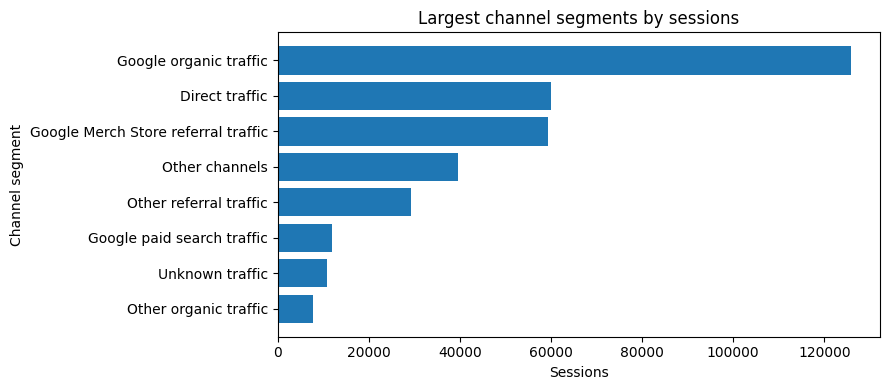

,segment_value_clean,segment_value,n_sessions,n_purchases,purchase_rate
175,Google organic traffic,google / organic,125911,1580,0.0125
3,Direct traffic,(direct) / (none),59967,307,0.0051
231,Google Merch Store referral traffic,shop.googlemerchandisestore.com / referral,59399,1332,0.0224
76,Other channels,<Other> / <Other>,39683,125,0.0031
78,Other referral traffic,<Other> / referral,29330,978,0.0333
173,Google paid search traffic,google / cpc,11947,47,0.0039
0,Unknown traffic,(data deleted) / (data deleted),10888,190,0.0175
77,Other organic traffic,<Other> / organic,7767,34,0.0044


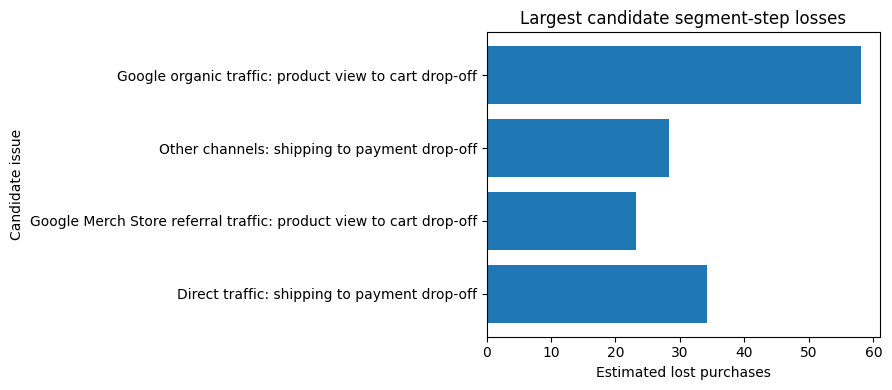

,week_start_date,segment_type,segment_value_clean,segment_value,step_from,step_to,earlier_step_sessions,conversion_gap,estimated_lost_purchases
10944,2021-01-25,channel_segment,Google organic traffic,google / organic,view_item,add_to_cart,3444,0.0591,58.1238
10059,2021-01-18,channel_segment,Google organic traffic,google / organic,view_item,add_to_cart,2847,0.0427,37.8404
5256,2020-12-07,channel_segment,Direct traffic,(direct) / (none),add_shipping_info,add_payment_info,178,0.2514,34.1738
4386,2020-11-30,channel_segment,Direct traffic,(direct) / (none),add_shipping_info,add_payment_info,164,0.2779,32.5178
4446,2020-11-30,channel_segment,Other channels,<Other> / <Other>,add_shipping_info,add_payment_info,111,0.3576,28.3167
3516,2020-11-23,channel_segment,Other channels,<Other> / <Other>,add_shipping_info,add_payment_info,109,0.3337,26.0517
3456,2020-11-23,channel_segment,Direct traffic,(direct) / (none),add_shipping_info,add_payment_info,151,0.2385,25.7993
3779,2020-11-23,channel_segment,Google Merch Store referral traffic,shop.googlemerchandisestore.com / referral,view_item,add_to_cart,1533,0.0365,23.2252
1526,2020-11-09,channel_segment,Direct traffic,(direct) / (none),add_shipping_info,add_payment_info,117,0.2997,22.7299
2461,2020-11-16,channel_segment,Direct traffic,(direct) / (none),add_shipping_info,add_payment_info,120,0.2790,22.2764


In [9]:
#------------------------------------------------------------------------------
# 5.3 Display segment diagnostic graphs
#------------------------------------------------------------------------------
print_banner("5.3 Display segment diagnostic graphs")

# Compare funnel transitions by device
device_df = segment_base_weekly[segment_base_weekly["segment_type"].eq("device_category")].copy()
device_summary = device_df.groupby("segment_value", as_index=False)[["n_sessions","view_item","add_to_cart","begin_checkout","add_shipping_info","add_payment_info","purchase"]].sum()
device_rates = pd.DataFrame({"device_category": device_summary["segment_value"],
    "view_to_cart": np.minimum(safe_divide(device_summary["add_to_cart"], device_summary["view_item"]), 1.0),
    "cart_to_checkout": np.minimum(safe_divide(device_summary["begin_checkout"], device_summary["add_to_cart"]), 1.0),
    "checkout_to_shipping": np.minimum(safe_divide(device_summary["add_shipping_info"], device_summary["begin_checkout"]), 1.0),
    "shipping_to_payment": np.minimum(safe_divide(device_summary["add_payment_info"], device_summary["add_shipping_info"]), 1.0),
    "payment_to_purchase": np.minimum(safe_divide(device_summary["purchase"], device_summary["add_payment_info"]), 1.0)})

display(device_rates)

# Summarise the largest channel groups
channel_df = segment_base_weekly[segment_base_weekly["segment_type"].eq("channel_segment")].copy()
channel_summary = channel_df.groupby(["segment_value","segment_value_clean"], as_index=False)[["n_sessions","n_purchases"]].sum()
channel_summary["purchase_rate"] = safe_divide(channel_summary["n_purchases"], channel_summary["n_sessions"])
channel_summary = channel_summary.sort_values("n_sessions", ascending=False).head(8)

plt.figure(figsize=(9, 4))
plt.barh(channel_summary.sort_values("n_sessions")["segment_value_clean"], channel_summary.sort_values("n_sessions")["n_sessions"])
plt.title("Largest channel segments by sessions")
plt.xlabel("Sessions")
plt.ylabel("Channel segment")
plt.tight_layout(); plt.show()

display(channel_summary[["segment_value_clean","segment_value","n_sessions","n_purchases","purchase_rate"]])

# Preview the largest candidate losses before ranking
candidate_preview = segment_step_metrics_weekly[segment_step_metrics_weekly["issue_candidate_flag"]].sort_values("estimated_lost_purchases", ascending=False).head(10).copy()
candidate_preview["short_label"] = candidate_preview.apply(format_issue_label, axis=1)

if len(candidate_preview) > 0:
    plot_preview = candidate_preview.sort_values("estimated_lost_purchases", ascending=True)
    plt.figure(figsize=(9, 4))
    plt.barh(plot_preview["short_label"], plot_preview["estimated_lost_purchases"])
    plt.title("Largest candidate segment-step losses")
    plt.xlabel("Estimated lost purchases")
    plt.ylabel("Candidate issue")
    plt.tight_layout(); plt.show()
    display(candidate_preview[["week_start_date","segment_type","segment_value_clean","segment_value","step_from","step_to","earlier_step_sessions","conversion_gap","estimated_lost_purchases"]])
else:
    print("No segment-step rows currently pass the issue candidate rules.")

# 6.0 Rank weekly Top Issues

The Top Issues table converts the segment-step diagnostics into a weekly prioritisation output. The ranking focuses on practical decision support by combining estimated impact with conversion gap severity, while a minimum volume rule avoids overreacting to small noisy segments.

**Process**:
1. Filter to valid issue candidates where the segment has at least 100 earlier step sessions.
2. Rank each candidate by estimated lost purchases to represent potential business impact.
3. Rank each candidate by conversion gap to represent severity relative to the weekly baseline.
4. Combine the two ranks using `0.70 * impact_rank + 0.30 * severity_rank`.
5. Create a readable `issue_label` from the cleaned segment label and funnel transition.
6. Keep the technical fields separately, including `segment_type`, `segment_value`, `segment_value_raw`, `step_from`, and `step_to`.
7. Save `top_issues_weekly.csv` directly to the Power BI latest folder.
8. Display the remaining noisy-label review count for the dashboard facing channel labels.
9. Display the latest Top 3 issues with enough evidence columns to support interpretation in Notebook 04 and the final dashboard.

In [10]:
#------------------------------------------------------------------------------
# 6.1 Create readable labels and save weekly Top Issues
#------------------------------------------------------------------------------
print_banner("6.1 Create readable labels and save weekly Top Issues")

# Set the final Top Issues column order
top_issue_cols = ["week_start_date","issue_rank_within_week","issue_label","segment_type","segment_value_display","segment_value_clean",
    "segment_value_raw","segment_value","step_from","step_to","earlier_step_sessions","later_step_sessions",
    "current_step_conversion","baseline_step_conversion","conversion_gap","lost_next_step_sessions",
    "estimated_lost_purchases","issue_score"]

# Rank issue candidates by impact and severity
top_issues_full_ranked = segment_step_metrics_weekly[segment_step_metrics_weekly["issue_candidate_flag"]].copy()
top_issues_full_ranked["impact_rank"] = top_issues_full_ranked.groupby("week_start_date")["estimated_lost_purchases"].transform(lambda s: pct_rank(s.fillna(0)))
top_issues_full_ranked["severity_rank"] = top_issues_full_ranked.groupby("week_start_date")["conversion_gap"].transform(lambda s: pct_rank(s.fillna(0)))
top_issues_full_ranked["issue_score"] = 0.70 * top_issues_full_ranked["impact_rank"] + 0.30 * top_issues_full_ranked["severity_rank"]
top_issues_full_ranked["issue_label"] = top_issues_full_ranked.apply(format_issue_label, axis=1)

# Keep the highest scoring issues for each week
top_issues_full_ranked = top_issues_full_ranked.sort_values(["week_start_date","issue_score","estimated_lost_purchases"], ascending=[True, False, False]).reset_index(drop=True)
top_issues_full_ranked["issue_rank_within_week"] = top_issues_full_ranked.groupby("week_start_date").cumcount() + 1
top_issues_weekly = top_issues_full_ranked.groupby("week_start_date", group_keys=False).head(TOP_ISSUES_PER_WEEK)[top_issue_cols].copy()
top_issues_weekly = top_issues_weekly.sort_values(["week_start_date","issue_rank_within_week"]).reset_index(drop=True)

# Rebuild issue labels using cleaned segment names
top_issues_weekly["segment_value_raw"] = top_issues_weekly["segment_value"]
top_issues_weekly["segment_value_display"] = top_issues_weekly.apply(
    lambda r: clean_channel_segment(r["segment_value"]) if r["segment_type"] == "channel_segment" else str(r["segment_value"]), axis=1)
top_issues_weekly["segment_value_clean"] = top_issues_weekly["segment_value_display"]
top_issues_weekly["issue_label"] = top_issues_weekly.apply(format_issue_label, axis=1)
top_issues_weekly = top_issues_weekly[top_issue_cols].copy()

save_csv(top_issues_weekly, PBI_LATEST_DIR / "top_issues_weekly.csv")

print("Top Issues rows:", len(top_issues_weekly))
display_cols = ["week_start_date","issue_rank_within_week","issue_label","segment_type","segment_value_clean","segment_value","step_from","step_to","estimated_lost_purchases","issue_score"]
display(top_issues_weekly[display_cols])

# Check for remaining noisy dashboard labels
technical_pattern = r"safeframe|googlesyndication|[a-f0-9]{24,}|\.com|\.org|\.net|\.ru|appspot|doubleclick|2mdn"
# Combine outputs for the label audit
label_check_df = pd.concat([
    segment_step_metrics_weekly.assign(output_table="segment_step_metrics_weekly"),
    top_issues_weekly.assign(output_table="top_issues_weekly")], ignore_index=True)

label_check_df = label_check_df[
    label_check_df["segment_type"].eq("channel_segment") &
    label_check_df["segment_value_display"].astype(str).str.lower().str.contains(technical_pattern, regex=True, na=False)].copy()

print("Remaining noisy dashboard labels:", len(label_check_df))
display(label_check_df[["output_table","segment_value","segment_value_display"]].drop_duplicates().head(50))



------------------------------------------------------------------------------
6.1 Create readable labels and save weekly Top Issues
------------------------------------------------------------------------------
Saved -> /content/drive/MyDrive/Capstone_Project/powerbi_extracts/latest/top_issues_weekly.csv
Top Issues rows: 41


,week_start_date,issue_rank_within_week,issue_label,segment_type,segment_value_clean,segment_value,step_from,step_to,estimated_lost_purchases,issue_score
0,2020-10-26,1,desktop: product view to cart drop-off,device_category,desktop,desktop,view_item,add_to_cart,0.5642,1.0000
1,2020-10-26,2,Google organic traffic: product view to cart d...,channel_segment,Google organic traffic,google / organic,view_item,add_to_cart,0.3240,0.6500
2,2020-11-02,1,Google organic traffic: shipping to payment dr...,channel_segment,Google organic traffic,google / organic,add_shipping_info,add_payment_info,13.8388,0.9625
3,2020-11-02,2,Direct traffic: shipping to payment drop-off,channel_segment,Direct traffic,(direct) / (none),add_shipping_info,add_payment_info,8.4204,0.9125
4,2020-11-02,3,mobile: payment to purchase drop-off,device_category,mobile,mobile,add_payment_info,purchase,5.0155,0.7500
5,2020-11-09,1,Direct traffic: shipping to payment drop-off,channel_segment,Direct traffic,(direct) / (none),add_shipping_info,add_payment_info,22.7299,1.0000
6,2020-11-09,2,Google organic traffic: shipping to payment dr...,channel_segment,Google organic traffic,google / organic,add_shipping_info,add_payment_info,10.3266,0.8571
7,2020-11-09,3,Google organic traffic: payment to purchase dr...,channel_segment,Google organic traffic,google / organic,add_payment_info,purchase,7.2300,0.7143
8,2020-11-16,1,Direct traffic: shipping to payment drop-off,channel_segment,Direct traffic,(direct) / (none),add_shipping_info,add_payment_info,22.2764,1.0000
9,2020-11-16,2,Google paid search traffic: product view to ca...,channel_segment,Google paid search traffic,google / cpc,view_item,add_to_cart,5.9345,0.8000


Remaining noisy dashboard labels: 0


,output_table,segment_value,segment_value_display



------------------------------------------------------------------------------
6.2 Display latest Top 3 issues
------------------------------------------------------------------------------


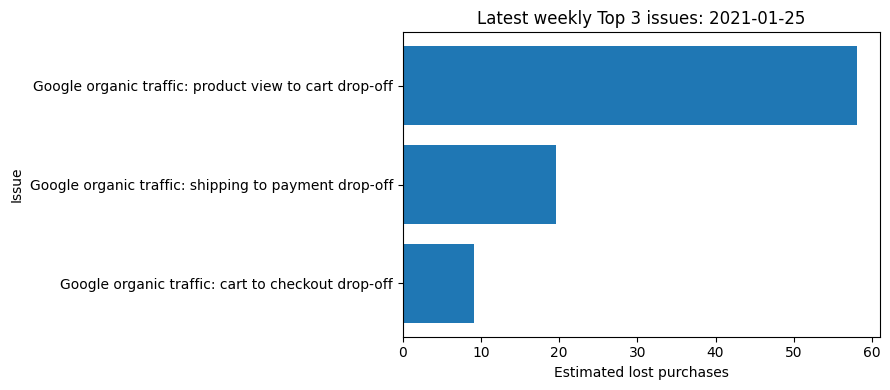

,issue_rank_within_week,issue_label,segment_value_clean,segment_value,earlier_step_sessions,current_step_conversion,baseline_step_conversion,conversion_gap,estimated_lost_purchases,issue_score
38,1,Google organic traffic: product view to cart d...,Google organic traffic,google / organic,3444,0.1164,0.1756,0.0591,58.1238,0.9684
39,2,Google organic traffic: shipping to payment dr...,Google organic traffic,google / organic,197,0.5990,0.7362,0.1372,19.6257,0.9632
40,3,Google organic traffic: cart to checkout drop-off,Google organic traffic,google / organic,401,0.4913,0.5341,0.0428,9.1728,0.8263


In [11]:
#------------------------------------------------------------------------------
# 6.2 Display latest Top 3 issues
#------------------------------------------------------------------------------
print_banner("6.2 Display latest Top 3 issues")

# Select the latest reporting week
latest_week = top_issues_weekly["week_start_date"].max()
latest_top_issues = top_issues_weekly[top_issues_weekly["week_start_date"].eq(latest_week)].sort_values("estimated_lost_purchases", ascending=True).copy()

# Plot latest week estimated lost purchases
plt.figure(figsize=(9, 4))
plt.barh(latest_top_issues["issue_label"], latest_top_issues["estimated_lost_purchases"])
plt.title(f"Latest weekly Top 3 issues: {latest_week.date()}")
plt.xlabel("Estimated lost purchases")
plt.ylabel("Issue")
plt.tight_layout(); plt.show()

latest_display_cols = ["issue_rank_within_week","issue_label","segment_value_clean","segment_value","earlier_step_sessions","current_step_conversion","baseline_step_conversion","conversion_gap","estimated_lost_purchases","issue_score"]
display(latest_top_issues.sort_values("issue_rank_within_week")[latest_display_cols])
